🔄 Fetching historical data for AAPL...


/tmp/ipykernel_3629/3337467576.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2026-06-20")
[*********************100%***********************]  1 of 1 completed


🛠️ Engineering Technical Indicators (MA, RSI, MACD)...
📊 Training Data: 1661
📊 Testing Data: 416
🤖 Training Random Forest...

📈 MODEL PERFORMANCE
MAE  : $21.24
MSE  : 860.29
RMSE : $29.33


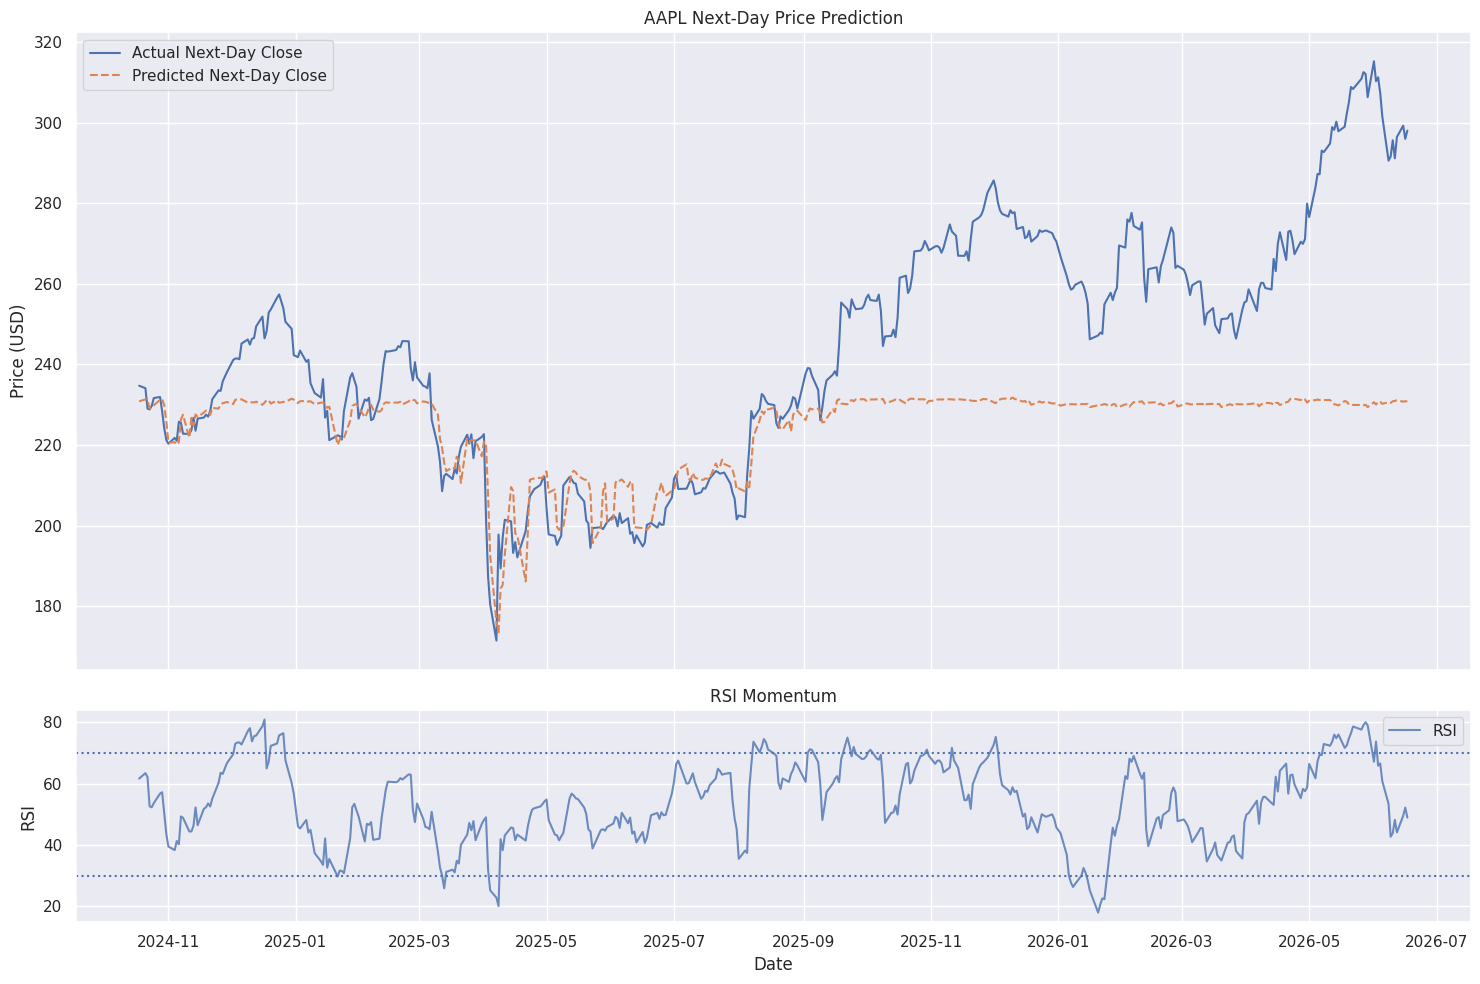


🔮 NEXT TRADING DAY FORECAST
Last Close Price       : $295.95
Predicted Next Close   : $230.81
Expected Change        : -22.01%


In [1]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 8)

ticker = "AAPL"
print(f"🔄 Fetching historical data for {ticker}...")
data = yf.download(ticker, start="2018-01-01", end="2026-06-20")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.dropna()


print("🛠️ Engineering Technical Indicators (MA, RSI, MACD)...")

data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

delta = data['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

ema_gain = gain.ewm(com=13, adjust=False).mean()
ema_loss = loss.ewm(com=13, adjust=False).mean()

rs = ema_gain / (ema_loss + 1e-10)
data['RSI'] = 100 - (100 / (1 + rs))

exp12 = data['Close'].ewm(span=12, adjust=False).mean()
exp26 = data['Close'].ewm(span=26, adjust=False).mean()

data['MACD'] = exp12 - exp26
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

data['Daily_Return'] = data['Close'].pct_change()
data['Volume_Change'] = data['Volume'].pct_change()


data['Target'] = data['Close'].shift(-1)

data = data.dropna()


features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'MA10',
    'MA50',
    'RSI',
    'MACD',
    'MACD_Signal',
    'Volume_Change'
]

X = data[features]
y = data['Target']

split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"📊 Training Data: {len(X_train)}")
print(f"📊 Testing Data: {len(X_test)}")

print("🤖 Training Random Forest...")

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("\n" + "="*50)
print("📈 MODEL PERFORMANCE")
print("="*50)
print(f"MAE  : ${mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : ${rmse:.2f}")
print("="*50)


predictions_series = pd.Series(
    predictions,
    index=y_test.index
)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

ax1.plot(
    y_test.index,
    y_test,
    label='Actual Next-Day Close',
    linewidth=1.5
)

ax1.plot(
    predictions_series.index,
    predictions_series,
    '--',
    label='Predicted Next-Day Close',
    linewidth=1.5
)

ax1.set_title(f'{ticker} Next-Day Price Prediction')
ax1.set_ylabel('Price (USD)')
ax1.legend()

ax2.plot(
    X_test.index,
    X_test['RSI'],
    label='RSI',
    alpha=0.8
)

ax2.axhline(70, linestyle=':')
ax2.axhline(30, linestyle=':')

ax2.set_title('RSI Momentum')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('final_stock_prediction_report.png', dpi=300)
plt.show()

latest_snapshot = X.iloc[[-1]]

next_day_prediction = model.predict(latest_snapshot)[0]

last_close = data['Close'].iloc[-1]

change_pct = (
    (next_day_prediction - last_close)
    / last_close
) * 100

print("\n" + "="*50)
print("🔮 NEXT TRADING DAY FORECAST")
print("="*50)
print(f"Last Close Price       : ${last_close:.2f}")
print(f"Predicted Next Close   : ${next_day_prediction:.2f}")
print(f"Expected Change        : {change_pct:.2f}%")
print("="*50)